## Script to visualize the DWD phenology data downloaded from: https://opendata.dwd.de/climate_environment/CDC/grids_germany/annual/phenology for Fagus Sylvatica.


## Packages

In [ ]:
import matplotlib.pyplot as plot
from functions.dwd_to_xarray import *
from functions.plot_functions import *
from functions.lc_filter import *
from functions.landcover_loader import *
from functions.mk_test import *
import pymannkendall as mk

## Read DWD

In [ ]:
dwd_raw = dwd_to_xarray(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\DWD\beech_raster_spring_long", r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\DWD\beech_raster_fall_long").rio.write_crs("EPSG:31467")

## Filter DWD by landcover

In [ ]:
lc = landcover_loader_dwd(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\gis\geodata\bioreservat_rhön.geojson", as_single_layer = True, crs = "EPSG:31467")
dwd = lc_filter_dwd(dwd_raw, lc, class_codes = [60])

In [ ]:
dwd.isel(time=0).sel(band="SOS").plot(cmap='viridis', size=6)
#plt.show()

## Calculate LOS

In [ ]:
LOS = dwd.sel(band="EOS") - dwd.sel(band="SOS")
LOS = LOS.assign_coords(band="LOS").expand_dims('band')
dwd = xr.concat([dwd, LOS], dim='band')

#dwd.plot.hist(bins=100)

## Timeseries ridgeplot

In [ ]:
ridgeplot_now = False
if ridgeplot_now: xarray_ridgeplot(dwd, bands =["SOS", "EOS", "LOS"], title="Timeseries of Beech phenology according to DWD")

## Simple Timeseries

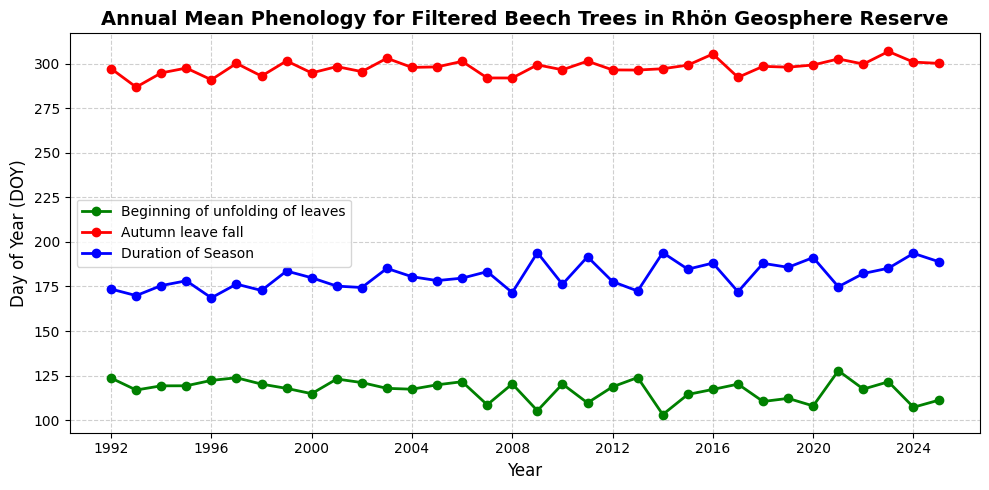

In [18]:
annual_mean = dwd.mean(dim=["y", "x"], skipna=True)

fig, ax = plt.subplots(figsize=(10, 5))
annual_mean.sel(band="SOS").plot.line(ax=ax, color="green", marker="o", label="Beginning of unfolding of leaves", linewidth=2)
annual_mean.sel(band="EOS").plot.line(ax=ax, color="red", marker="o", label="Autumn leave fall", linewidth=2)
annual_mean.sel(band="LOS").plot.line(ax=ax, color="blue", marker="o", label="Duration of Season", linewidth=2)

ax.set_title("Annual Mean Phenology for Filtered Beech Trees in Rhön Geosphere Reserve", fontsize=14, weight="bold")
ax.set_ylabel("Day of Year (DOY)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)


ax.legend(frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Mann-Kendall test
similar to MODIS_timeseries

In [ ]:
till2000 = False

sos_np = annual_mean.sel(band="SOS").values
eos_np = annual_mean.sel(band="EOS").values
los_np = annual_mean.sel(band="LOS").values
if till2000: sos_np = annual_mean.sel(band="SOS").sel(time=slice('2000-01-01', None)).values
if till2000: eos_np = annual_mean.sel(band="EOS").sel(time=slice('2000-01-01', None)).values
if till2000: los_np = annual_mean.sel(band="LOS").sel(time=slice('2000-01-01', None)).values


print("MK SoS:")
mk_sos = mk.original_test(sos_np)
print(mk_sos)
print()

print("MK EOS:")
mk_eos = mk.original_test(eos_np)
print(mk_eos)
print()

print("MK LOS:")
mk_los = mk.original_test(los_np)
print(mk_los)


In [17]:
SAVE = True

if SAVE:

    %store sos_np
    %store eos_np
    %store los_np

Stored 'sos_np' (ndarray)
Stored 'eos_np' (ndarray)
Stored 'los_np' (ndarray)
